# 03 · Feature Engineering & Selection

**Notebook:** 03 of 04  
**Goal:** Engineer new features from domain knowledge and select the most important ones for modeling.

### What this notebook covers
- Create derived features (total_price, tax_ratio)
- Feature selection: Pearson correlation filter
- Feature selection: ExtraTreesClassifier importance ranking
- Save final feature set for modeling 

In [24]:
import pandas as pd
import numpy as np
import plotly.express as px

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [ ]:

# ── Load EDA-clean data from notebook 02 ─────────────────────────────────────
df = pd.read_csv("data/02_eda_clean.csv")
print(f"Loaded data → shape: {df.shape}")
df.head(3)

Loaded data → shape: (19504, 17)


,Month,product_category,Product_Subcategory,Quantity,Unit_Price,Price,Tax,Payment_mode,Store_type,Reviews,Income,city,Gender,Marital_status,Education_Level,Profession_Type,Return
0,January,Books,Fiction,3,359,1077,188.475,Mobile Payments,e-Shop,1.0,67501.0,Hyderabad,M,0,PhD,Others,1
1,January,Clothing,Women,5,1129,5645,592.725,Credit Card,TeleShop,1.0,102738.0,Bangalore,M,1,Master,Salaried,1
2,January,Home and kitchen,Bath,4,1327,5308,696.675,Debit Card,MBR,1.0,104013.0,Kolkata,M,1,Basic,Salaried,1


# Feature engineering

In [26]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

## **Categorical Unique Values Check**

We analyzed the number of unique values in each column to help us decide:

- If a feature has too many unique values, we will group rare categories together to less the number of values.
- We will choose the appropriate encoding technique based on the number of unique values in each column. 

In [ ]:
df_Cat = df.select_dtypes(include="object")

for col in df_Cat.columns :
    print(f"Column {col} has {df_Cat[col].nunique()} values")

Column product_category has 6 values
Column Product_Subcategory has 16 values
Column Payment_mode has 4 values
Column city has 10 values


In [44]:
df.describe()

,Quantity,Unit_Price,Price,Tax,Reviews,Income,Return,total_price,tax_ratio
count,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000,19504.000000
mean,3.097724,776.168222,2393.920991,241.235454,3.882639,70516.888074,0.104953,2635.156445,0.103398
std,1.446259,414.249426,1795.395383,182.887380,1.414655,37418.384648,0.306500,1968.175145,0.026386
min,1.000000,70.000000,70.000000,7.350000,1.000000,7157.000000,0.000000,77.350000,0.020943
25%,2.000000,417.000000,945.000000,95.760000,3.000000,37950.000000,0.000000,1046.158750,0.104863
50%,3.000000,773.000000,1930.000000,190.785000,4.000000,69293.000000,0.000000,2126.020000,0.104937
75%,4.000000,1135.000000,3522.000000,349.965000,5.000000,99534.000000,0.000000,3875.235000,0.104968
max,5.000000,1500.000000,7500.000000,787.500000,5.000000,159984.000000,1.000000,8287.500000,0.524641


## 1- create derived columns to help model learn better.

### total_price

In [27]:
df['total_price'] = df['Price'] + df['Tax'] 

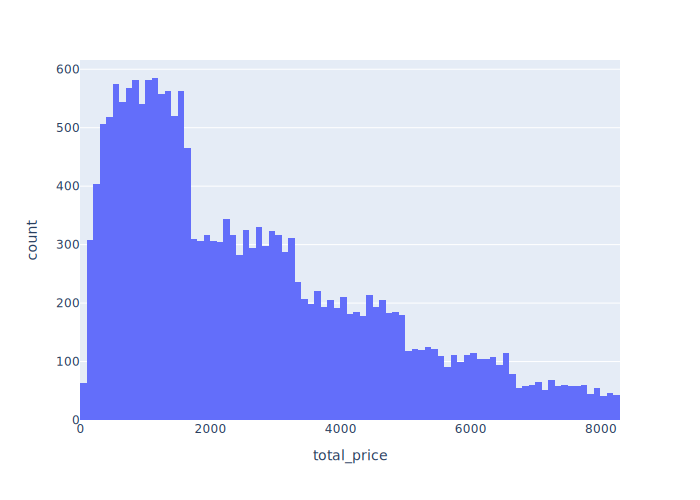

In [28]:
px.histogram(df, x= "total_price")

## tax_ratio

In [29]:
df['tax_ratio'] = df['Tax'] / (df['Price'] + 1)

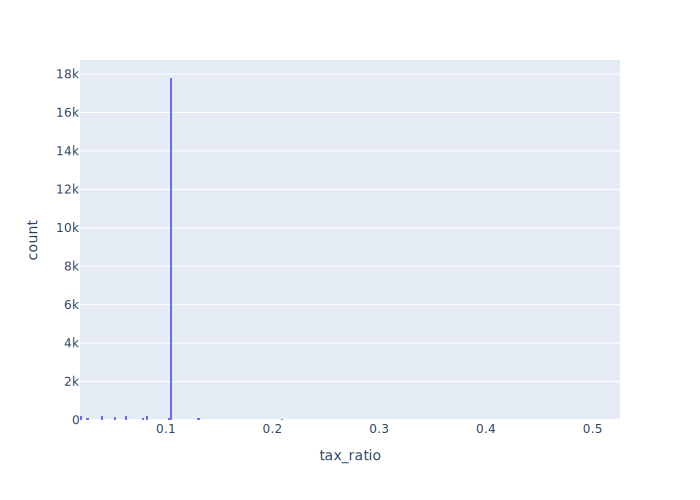

In [30]:
px.histogram(df, x= "tax_ratio")

# Choose best and importan Feature

## this step will Filter features by choose important ones by (correlation and Extraclassifier )

## 1-corrolation

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19504 entries, 0 to 19503
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month                19504 non-null  object 
 1   product_category     19504 non-null  object 
 2   Product_Subcategory  19504 non-null  object 
 3   Quantity             19504 non-null  int64  
 4   Unit_Price           19504 non-null  int64  
 5   Price                19504 non-null  int64  
 6   Tax                  19504 non-null  float64
 7   Payment_mode         19504 non-null  object 
 8   Store_type           19504 non-null  object 
 9   Reviews              19504 non-null  float64
 10  Income               19504 non-null  float64
 11  city                 19504 non-null  object 
 12  Gender               19504 non-null  object 
 13  Marital_status       19504 non-null  int64  
 14  Education_Level      19504 non-null  object 
 15  Profession_Type      19504 non-null 

In [32]:
df_Cat = df.select_dtypes(include= "number")
df_Cat.columns

Index(['Quantity', 'Unit_Price', 'Price', 'Tax', 'Reviews', 'Income',
       'Marital_status', 'Return', 'total_price', 'tax_ratio'],
      dtype='object')

In [33]:
df_Cat = df.select_dtypes(include= "number")
corr = df_Cat.corr()['Return'].sort_values(ascending=False)
print(corr)

Return            1.000000
Quantity          0.264764
Price             0.181667
total_price       0.168094
Income            0.096515
Tax               0.025561
Unit_Price        0.016190
Marital_status    0.004795
tax_ratio        -0.165521
Reviews          -0.541104
Name: Return, dtype: float64


In [34]:
corr_matrix = df_Cat.corr()

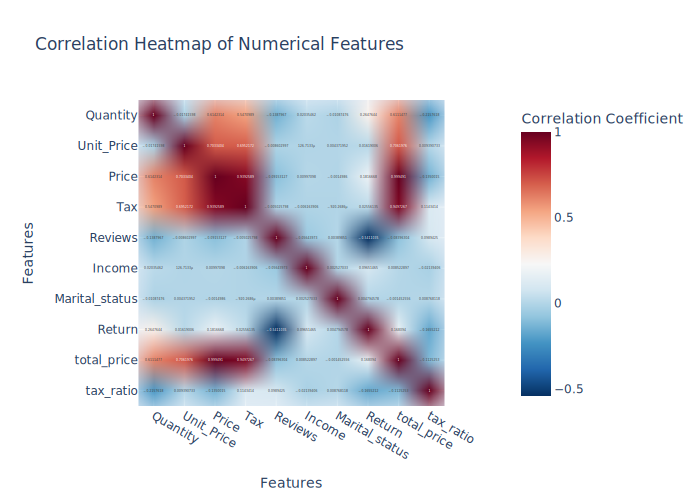

In [35]:
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Heatmap of Numerical Features',
    labels=dict(color='Correlation Coefficient')
)

fig.update_layout(
    width=1500,
    height=900,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

In [36]:
df_Cat = df.select_dtypes(include="object")

for col in df_Cat.columns :
    print(f"Column {col} has {df_Cat[col].nunique()} values")

Column Month has 12 values
Column product_category has 6 values
Column Product_Subcategory has 16 values
Column Payment_mode has 4 values
Column Store_type has 4 values
Column city has 10 values
Column Gender has 2 values
Column Education_Level has 5 values
Column Profession_Type has 3 values


In [37]:
df.select_dtypes(include="object").columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Payment_mode',
       'Store_type', 'city', 'Gender', 'Education_Level', 'Profession_Type'],
      dtype='object')

In [38]:
df.select_dtypes(include=["number"]).columns

Index(['Quantity', 'Unit_Price', 'Price', 'Tax', 'Reviews', 'Income',
       'Marital_status', 'Return', 'total_price', 'tax_ratio'],
      dtype='object')

# 2-ExtraTreesClassifier

#### - Feature Importance Analysis by ExtraTreesClassifier -

- This script prepares feature and evaluates feature importance
using an ExtraTreesClassifier.


Why ExtraTrees:
----------------
ExtraTrees (Extremely Randomized Trees) is a tree-based ensemble method that:
- Handles both numerical and categorical inputs after encoding.
- Is resistant to noise and outliers.
- Provides reliable estimates of feature importance, guiding feature selection
  and model refinement.

Key Steps:
------------

1. Encode categorical features:
  
2. Combine encoded categorical and numeric usage features.

3. Train ExtraTreesClassifier:
   - Robust to outliers, no scaling needed.
   - Provides reliable feature importance.

4. Extract and sort feature importance to identify key drivers of return.


## ------------------------- This explain coming code ----------------------------------- ##

In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier

cat_cols = [

   'Month', 'product_category', 'Product_Subcategory', 'Payment_mode',
       'Store_type', 'city', 'Gender', 'Education_Level', 'Profession_Type',
]

num_cols = ['Quantity', 'Unit_Price', 'Tax', 'Reviews', 'Income',
       'Marital_status', 'Price',  "total_price", "tax_ratio"]

df_encoded = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


X = df_encoded[cat_cols + num_cols]
y = df_encoded['Return']

In [40]:
# Fit ExtraTreesClassifier

model = ExtraTreesClassifier(random_state=42)
model.fit(X, y)

#  Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

#  Show top features
importances_sorted

tax_ratio              0.369680
Reviews                0.230011
Quantity               0.067953
Tax                    0.055899
Price                  0.038334
total_price            0.030570
Unit_Price             0.024145
Product_Subcategory    0.023365
Income                 0.022222
Month                  0.021806
Payment_mode           0.021619
city                   0.017285
product_category       0.016111
Education_Level        0.015172
Store_type             0.013786
Profession_Type        0.012997
Marital_status         0.009782
Gender                 0.009264
dtype: float64

In [41]:
# # Drop low columns importances
df.drop(["Gender", "Marital_status", "Profession_Type", "Education_Level", "Store_type", "Month" ], inplace= True, axis= 1)

In [42]:
# ── Save final features for notebook 04 ──────────────────────────────────────
df.to_csv("data/03_features.csv", index=False)
print(f"Saved final features → data/03_features.csv  |  shape: {df.shape}")
print("Features:", df.columns.tolist())

Saved final features → data/03_features.csv  |  shape: (19504, 13)
Features: ['product_category', 'Product_Subcategory', 'Quantity', 'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Reviews', 'Income', 'city', 'Return', 'total_price', 'tax_ratio']
